# Depression Detection + Explainability (SHAP & LIME)
**Đồ án Khoa học Dữ liệu ứng dụng**

Pipeline: Load data → Tiền xử lý → Fine-tune BERT → SHAP → LIME

## Bước 0 — Cài thư viện

In [ ]:
!pip install transformers datasets shap lime torch scikit-learn -q

## Bước 1 — Load dataset từ HuggingFace

In [ ]:
from datasets import load_dataset
import pandas as pd

# Load dataset
dataset = load_dataset('hugginglearners/reddit-depression-cleaned')
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['clean_text', 'is_depression'],
        num_rows: 7731
    })
})


In [ ]:
from sklearn.model_selection import train_test_split

# Chỉ có train split — tự chia 80/20
df = dataset['train'].to_pandas()

# Đổi tên cột nhãn cho thống nhất
df = df.rename(columns={'is_depression': 'label'})

df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'Train: {len(df_train)} | Test: {len(df_test)}')
print(f'Tỷ lệ depression (train): {df_train["label"].mean():.1%}')
print(f'Tỷ lệ depression (test):  {df_test["label"].mean():.1%}')
print('\n--- 3 dòng đầu ---')
df_train.head(3)

Train: 6184 | Test: 1547
Tỷ lệ depression (train): 49.5%
Tỷ lệ depression (test):  49.6%

--- 3 dòng đầu ---


,clean_text,label
0,she wa the only thing making me feel guilt or ...,1
1,nicolerichie yes we had the vhs i cried when t...,0
2,what keep me awake every night is trying to fi...,1


## Bước 2 — Khám phá dữ liệu (EDA)

--- Phân phối nhãn (train) ---
label
0    3120
1    3064
Name: count, dtype: int64

Tỷ lệ depression: 49.5%


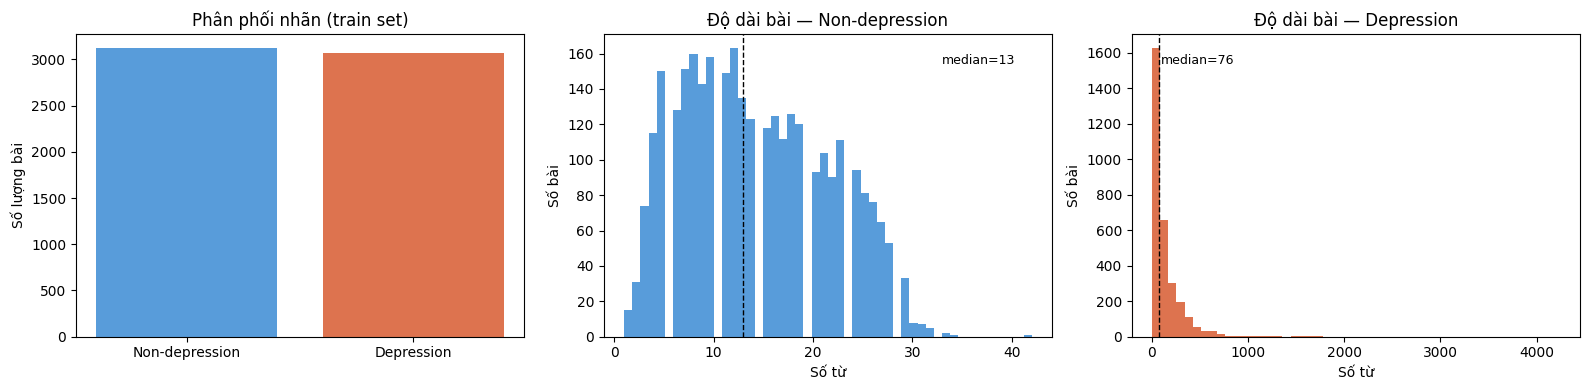

--- Thống kê độ dài bài đăng ---
Non-depression: median=13 từ | mean=14 | max=42
Depression: median=76 từ | mean=137 | max=4239


In [ ]:
import matplotlib.pyplot as plt

# Phân phối nhãn
print('--- Phân phối nhãn (train) ---')
print(df_train['label'].value_counts())
print(f'\nTỷ lệ depression: {df_train["label"].mean():.1%}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Biểu đồ 1: Label distribution ---
label_counts = df_train['label'].value_counts().sort_index()
axes[0].bar(['Non-depression', 'Depression'],
            label_counts.values,
            color=['#3B8BD4', '#D85A30'], alpha=0.85)
axes[0].set_title('Phân phối nhãn (train set)')
axes[0].set_ylabel('Số lượng bài')

# --- Biểu đồ 2 & 3: Tách riêng từng nhóm ---
text_col = 'clean_text'
df_train['text_len'] = df_train[text_col].str.split().str.len()

for ax, label, color, name in zip(
    [axes[1], axes[2]],
    [0, 1],
    ['#3B8BD4', '#D85A30'],
    ['Non-depression', 'Depression']
):
    subset = df_train[df_train['label'] == label]['text_len']
    ax.hist(subset, bins=50, color=color, alpha=0.85)
    ax.set_title(f'Độ dài bài — {name}')
    ax.set_xlabel('Số từ')
    ax.set_ylabel('Số bài')

    # Thêm thống kê
    ax.axvline(subset.median(), color='black', linestyle='--', linewidth=1)
    ax.text(subset.median() + 20, ax.get_ylim()[1] * 0.9,
            f'median={subset.median():.0f}', fontsize=9)

plt.tight_layout()
plt.show()

# In thống kê tóm tắt
print('--- Thống kê độ dài bài đăng ---')
for label, name in [(0, 'Non-depression'), (1, 'Depression')]:
    s = df_train[df_train['label'] == label]['text_len']
    print(f'{name}: median={s.median():.0f} từ | mean={s.mean():.0f} | max={s.max()}')

## Bước 3 — Tiền xử lý & Tokenize

In [ ]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = 'distilbert-base-uncased'  # Nhẹ hơn BERT gốc, phù hợp Colab free
MAX_LEN    = 128                         # Cắt bớt nếu bài quá dài
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Lấy đúng tên cột text
text_col = 'clean_text' if 'clean_text' in df_train.columns else 'text'
print(f'Dùng cột text: "{text_col}"')

# Dataset class
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = DepressionDataset(
    df_train[text_col].tolist(),
    df_train['label'].tolist(),
    tokenizer, MAX_LEN
)
test_dataset = DepressionDataset(
    df_test[text_col].tolist(),
    df_test['label'].tolist(),
    tokenizer, MAX_LEN
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train: {len(train_dataset)} samples | Test: {len(test_dataset)} samples')

Dùng cột text: "clean_text"
Train: 6184 samples | Test: 1547 samples


## Bước 4 — Fine-tune DistilBERT

In [ ]:
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
import torch.optim as optim
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Thiết bị: {device}')

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

EPOCHS         = 100
PATIENCE       = 10
SAVE_PATH      = './best_model'
BATCH_SIZE     = 16

best_acc       = 0.0
patience_count = 0
train_losses   = []
test_accs     = []
lrs            = []

# Tạo lại DataLoader với BATCH_SIZE rõ ràng
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False)
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Hiện loss realtime trên progress bar
        loop.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)

    # --- Eval ---
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
            preds     = outputs.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())

    acc        = accuracy_score(all_labels, all_preds)
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(avg_loss)
    test_accs.append(acc)
    lrs.append(current_lr)

    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.4f} | LR: {current_lr:.2e}', end='')

    # --- Early stopping + lưu model ---
    if acc > best_acc:
        best_acc       = acc
        patience_count = 0
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
        print(f'  ✓ Saved (best Acc so far)')
    else:
        patience_count += 1
        print(f'  (no improve {patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping tại epoch {epoch+1}!')
            break

print(f'\nBest Accuracy: {best_acc:.4f} — model đã lưu tại "{SAVE_PATH}"')

# --- Load lại model tốt nhất để eval cuối ---
model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to(device)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
        preds     = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['label'].numpy())

print('\n--- Classification Report (best model) ---')
print(classification_report(all_labels, all_preds,
      target_names=['Non-depression', 'Depression']))

Thiết bị: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train batches: 387 | Test batches: 97


Epoch 1/100 | Loss: 0.1282 | Acc: 0.9806 | LR: 2.00e-05

...

Epoch 13/100 | Loss: 0.0000 | Acc: 0.9813 | LR: 2.00e-05  (no improve 8/10)


Epoch 14/100 | Loss: 0.0000 | Acc: 0.9813 | LR: 2.00e-05  (no improve 9/10)


Epoch 15/100 | Loss: 0.0016 | Acc: 0.9761 | LR: 2.00e-05  (no improve 10/10)

Early stopping tại epoch 15!

Best Accuracy: 0.9813 — model đã lưu tại "./best_model"


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- Classification Report (best model) ---
                precision    recall  f1-score   support

Non-depression       0.98      0.99      0.98       780
    Depression       0.99      0.98      0.98       767

      accuracy                           0.98      1547
     macro avg       0.98      0.98      0.98      1547
  weighted avg       0.98      0.98      0.98      1547



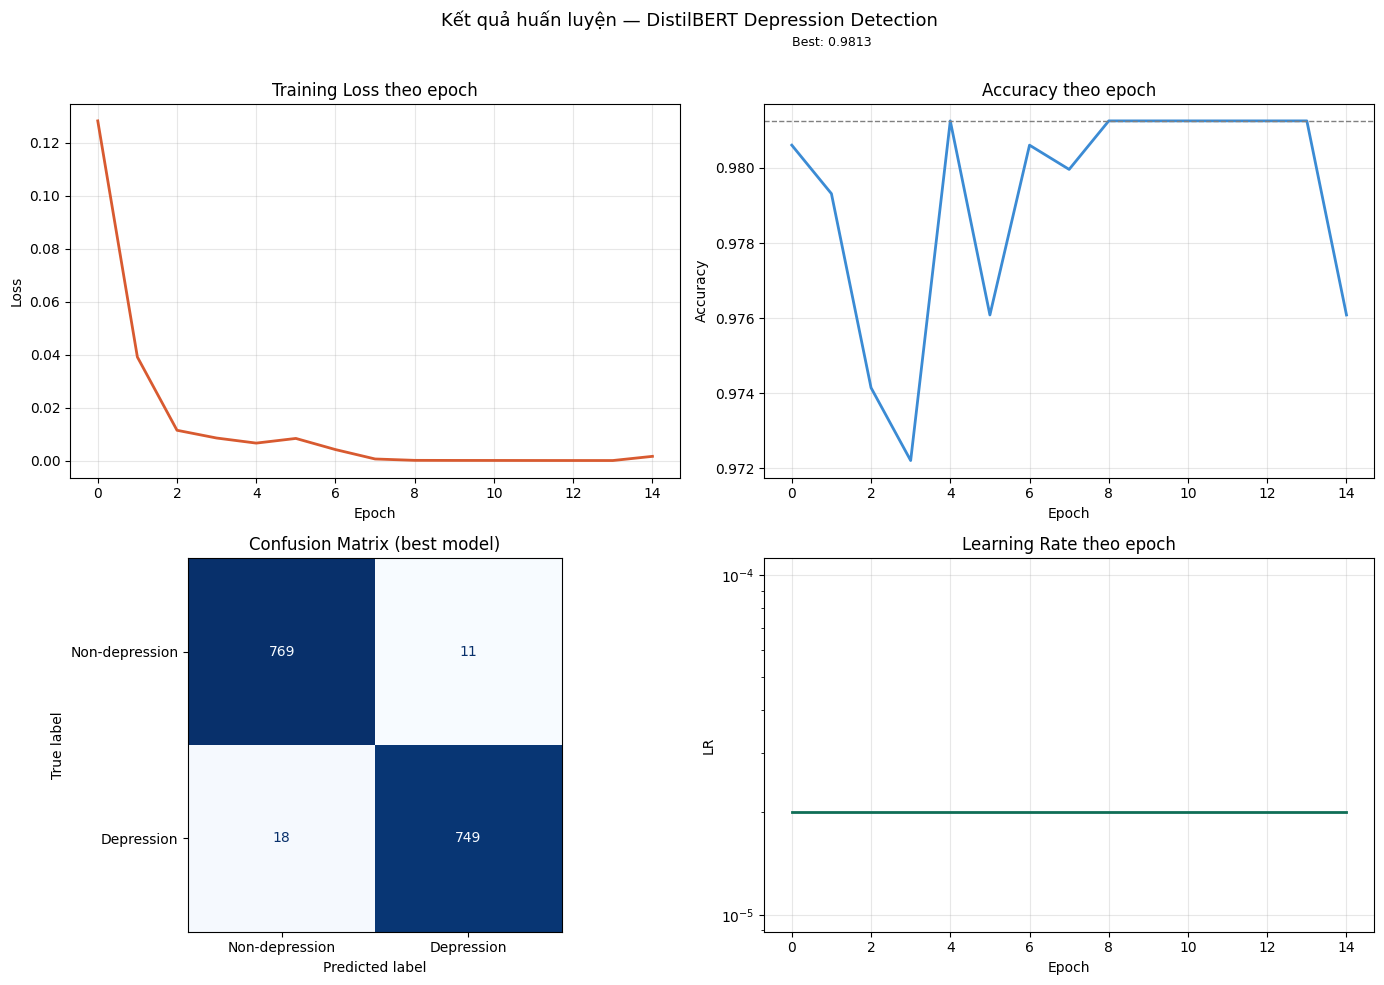

Đã lưu hình vào training_results.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Loss theo epoch ---
axes[0, 0].plot(train_losses, color='#D85A30', linewidth=2)
axes[0, 0].set_title('Training Loss theo epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(alpha=0.3)

# --- 2. Accuracy theo epoch ---
axes[0, 1].plot(test_accs, color='#3B8BD4', linewidth=2)
axes[0, 1].axhline(best_acc, color='gray', linestyle='--', linewidth=1)
axes[0, 1].text(0, best_acc + 0.002, f'Best: {best_acc:.4f}', fontsize=9)
axes[0, 1].set_title('Accuracy theo epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].grid(alpha=0.3)

# --- 3. Confusion Matrix ---
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-depression', 'Depression'])
disp.plot(ax=axes[1, 0], colorbar=False, cmap='Blues')
axes[1, 0].set_title('Confusion Matrix (best model)')

# --- 4. Learning Rate theo epoch ---
axes[1, 1].plot(lrs, color='#0F6E56', linewidth=2)
axes[1, 1].set_title('Learning Rate theo epoch')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('LR')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Kết quả huấn luyện — DistilBERT Depression Detection', fontsize=13)
plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu hình vào training_results.png')

In [ ]:
import pandas as pd

# Lấy index các câu bị dự đoán sai
errors = [(i, all_labels[i], all_preds[i]) for i in range(len(all_labels)) if all_labels[i] != all_preds[i]]

print(f'Tổng số câu sai: {len(errors)} / {len(all_labels)} ({len(errors)/len(all_labels):.1%})\n')

# Chia theo loại lỗi
fn = [(i, l, p) for i, l, p in errors if l == 1 and p == 0]  # Depression bị đoán là Non
fp = [(i, l, p) for i, l, p in errors if l == 0 and p == 1]  # Non bị đoán là Depression

print(f'False Negative (bỏ sót depression): {len(fn)}')
print(f'False Positive (báo nhầm depression): {len(fp)}\n')

# In mẫu 5 câu mỗi loại
text_col = 'clean_text'

print('='*60)
print('FALSE NEGATIVE — thực sự depression nhưng đoán là non:')
print('='*60)
for i, l, p in fn:
    text = df_test[text_col].iloc[i]
    print(f'\n[{i}] {text[:200]}{"..." if len(text)>200 else ""}')

print('\n' + '='*60)
print('FALSE POSITIVE — thực sự non-depression nhưng đoán là depression:')
print('='*60)
for i, l, p in fp:
    text = df_test[text_col].iloc[i]
    print(f'\n[{i}] {text[:200]}{"..." if len(text)>200 else ""}')

Tổng số câu sai: 29 / 1547 (1.9%)

False Negative (bỏ sót depression): 18
False Positive (báo nhầm depression): 11

FALSE NEGATIVE — thực sự depression nhưng đoán là non:

[28] please give me your grounding exercise to keep me busy a i make a long distance move happy thought appreciated

[333] i dont know what to do

[471] what should i do i am feeling down i don t know

[515] what can i say something major happened someone died friend of mine i am drunk i dont wan na call hotlines they know me already

[596] wa looking for this usually i go to bed st but today my wife is sleeping so i will go to km it wa about the time to do it

[649] god im stupid

[801] filler text filler tezt

[802] sorry for the clickbait title i just really want to share call this number if you re feeling down and hopefully it ll lift your spirit 0 99 0 i saw it on instagram

[847] i m alive because i wan na outlive all the mf who gave me truma

[851] i m absolutely fucking leathered i love you all

[980] title p

## Bước 5 — SHAP: giải thích toàn bộ dataset

In [ ]:
import shap

# Hàm predict_proba cho SHAP
def predict_proba(texts):
    model.eval()
    enc = tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding=True,
        truncation=True,
        return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        logits = model(**enc).logits
    return torch.softmax(logits, dim=1).cpu().numpy()

# Lấy 100 mẫu test để SHAP không quá chậm
text_col = 'clean_text' if 'clean_text' in df_test.columns else 'text'
sample_texts = df_test[text_col].tolist()[:]

# Tạo SHAP explainer (dùng Partition cho text)
explainer = shap.Explainer(predict_proba, shap.maskers.Text(tokenizer))
shap_values = explainer(sample_texts)

print('SHAP values computed!')
print(f'Shape: {shap_values.shape}')  # (n_samples, n_tokens, n_classes)

PartitionExplainer explainer:   9%|▉         | 138/1547 [02:39<20:56,  1.12it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  71%|███████   | 1099/1547 [20:27<08:41,  1.16s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  84%|████████▎ | 1293/1547 [24:04<03:00,  1.41it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 1548it [28:39,  1.12s/it]


SHAP values computed!
Shape: (1547, None, 2)


In [ ]:
import pickle

# Lưu lại
with open('shap_values.pkl', 'wb') as f:
    pickle.dump(shap_values, f)
print('Đã lưu shap_values.pkl')

# Load lại lần sau (khỏi chạy lại)
# with open('shap_values.pkl', 'rb') as f:
#     shap_values = pickle.load(f)
# print('Đã load shap_values!')

Đã lưu shap_values.pkl


=== Global: Top từ ảnh hưởng nhất đến dự đoán depression ===


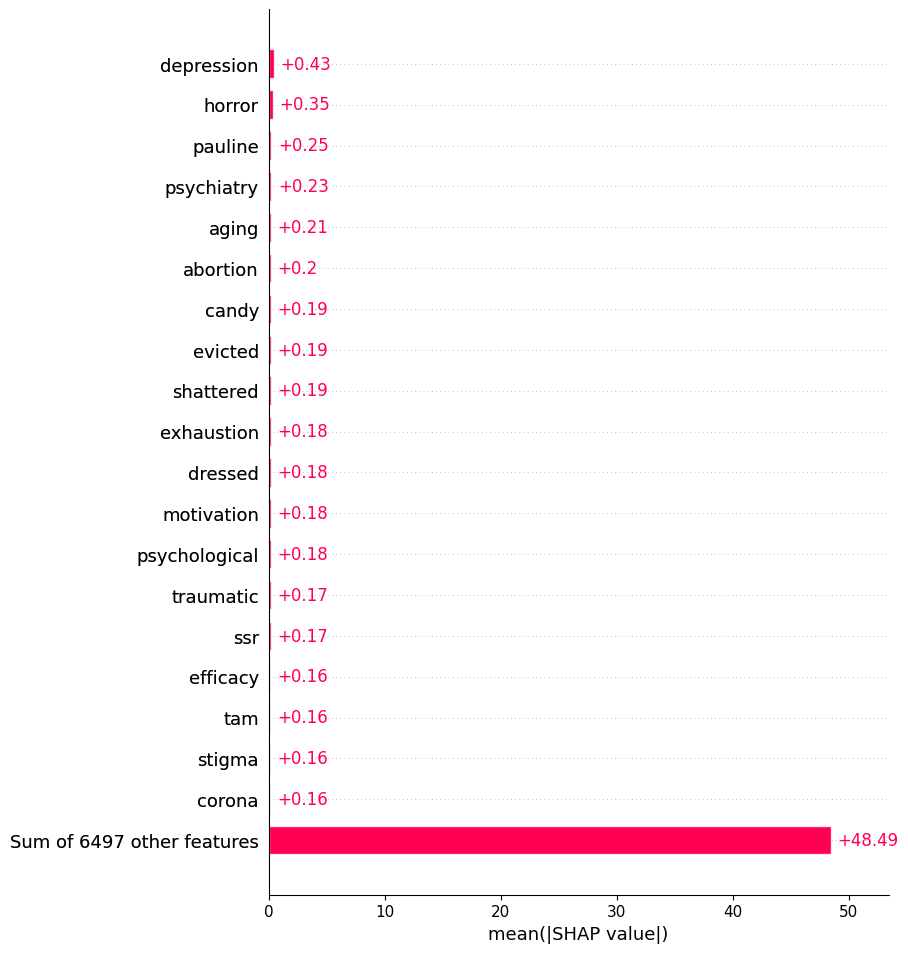

In [ ]:
# --- SHAP: Beeswarm plot (global — từ nào quan trọng nhất toàn dataset) ---
print('=== Global: Top từ ảnh hưởng nhất đến dự đoán depression ===')
shap.plots.bar(shap_values[:, :, 1], max_display=20)

In [ ]:
# --- SHAP: Text plot (local — giải thích 1 bài đăng cụ thể) ---
idx = 0   # Thay số này để xem bài đăng khác
print(f'Bài đăng #{idx}:')
print(sample_texts[idx])
print(f'\nNhãn thực: {df_test["label"].iloc[idx]}')
print(f'Xác suất depression: {predict_proba([sample_texts[idx]])[0][1]:.2%}')
print('\n--- SHAP Text Plot ---')
shap.plots.text(shap_values[idx, :, 1])

Bài đăng #0:
tolu pepper my dear ovulation pm and period make my life complicated the depression symptom emotional weariness edginess tiredness actual pain it s just a lot you are not alone si we are all frustrated with you sending hug

Nhãn thực: 1
Xác suất depression: 99.99%

--- SHAP Text Plot ---


## Bước 6 — LIME: giải thích từng bài đăng

In [ ]:
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(
    class_names=['Non-depression', 'Depression']
)

# Chọn 1 bài đăng để giải thích
idx = 0   # Thay số này để xem bài khác

text_col = 'clean_text' if 'clean_text' in df_test.columns else 'text'
sample_text = df_test[text_col].iloc[idx]

print(f'Bài đăng #{idx}:')
print(sample_text)
print(f'\nNhãn thực: {df_test["label"].iloc[idx]}')

# Tạo explanation
exp = lime_explainer.explain_instance(
    sample_text,
    lambda texts: predict_proba(texts),
    num_features=10,    # Hiện top 10 từ quan trọng nhất
    num_samples=500     # Số biến thể LIME tạo ra
)

# Hiển thị
print('\n--- Top từ quan trọng nhất (LIME) ---')
for word, weight in exp.as_list():
    direction = '→ depression' if weight > 0 else '→ non-depression'
    print(f'  "{word}"  |  weight: {weight:+.4f}  |  {direction}')

# Visualize trong Colab
exp.show_in_notebook(text=True)

Bài đăng #0:
tolu pepper my dear ovulation pm and period make my life complicated the depression symptom emotional weariness edginess tiredness actual pain it s just a lot you are not alone si we are all frustrated with you sending hug

Nhãn thực: 1

--- Top từ quan trọng nhất (LIME) ---
  "depression"  |  weight: +0.6893  |  → depression
  "tolu"  |  weight: -0.0979  |  → non-depression
  "tiredness"  |  weight: +0.0966  |  → depression
  "pepper"  |  weight: -0.0931  |  → non-depression
  "weariness"  |  weight: +0.0794  |  → depression
  "edginess"  |  weight: +0.0758  |  → depression
  "pain"  |  weight: +0.0753  |  → depression
  "emotional"  |  weight: +0.0690  |  → depression
  "my"  |  weight: -0.0592  |  → non-depression
  "dear"  |  weight: -0.0439  |  → non-depression


## Bước 7 — So sánh SHAP vs LIME trên cùng 1 bài

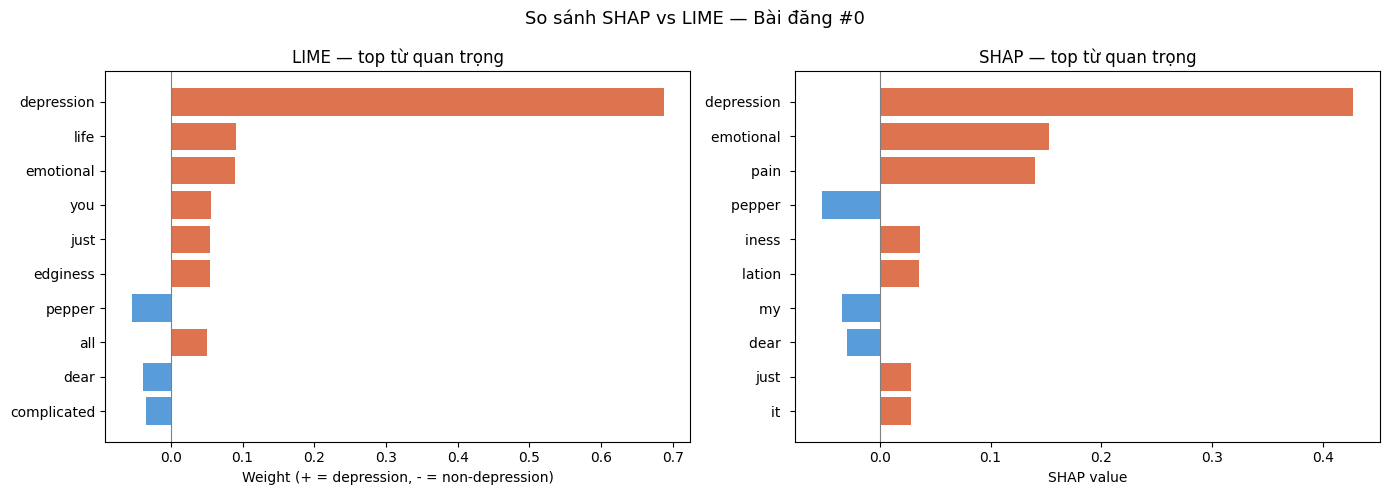


Từ xuất hiện ở cả SHAP và LIME: set()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Chọn bài đăng
idx = 0
text_col = 'clean_text' if 'clean_text' in df_test.columns else 'text'
sample_text = df_test[text_col].iloc[idx]

# --- LIME weights ---
lime_exp = lime_explainer.explain_instance(
    sample_text,
    lambda texts: predict_proba(texts),
    num_features=10,
    num_samples=500
)
lime_words   = [w for w, _ in lime_exp.as_list()[:10]]
lime_weights = [v for _, v in lime_exp.as_list()[:10]]

# --- SHAP weights (aggregate token-level về word-level) ---
shap_idx = df_test[text_col].tolist()[:100].index(sample_text) if sample_text in df_test[text_col].tolist()[:100] else 0
shap_vals = shap_values[shap_idx, :, 1]  # class depression
tokens    = shap_vals.data
values    = shap_vals.values

# Lấy top 10 token SHAP
top_idx      = np.argsort(np.abs(values))[-10:][::-1]
shap_words   = [tokens[i] for i in top_idx]
shap_weights = [values[i] for i in top_idx]

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_lime  = ['#D85A30' if w > 0 else '#3B8BD4' for w in lime_weights]
colors_shap  = ['#D85A30' if w > 0 else '#3B8BD4' for w in shap_weights]

ax1.barh(lime_words[::-1], lime_weights[::-1], color=colors_lime[::-1], alpha=0.85)
ax1.axvline(0, color='gray', linewidth=0.8)
ax1.set_title('LIME — top từ quan trọng')
ax1.set_xlabel('Weight (+ = depression, - = non-depression)')

ax2.barh(shap_words[::-1], shap_weights[::-1], color=colors_shap[::-1], alpha=0.85)
ax2.axvline(0, color='gray', linewidth=0.8)
ax2.set_title('SHAP — top từ quan trọng')
ax2.set_xlabel('SHAP value')

plt.suptitle(f'So sánh SHAP vs LIME — Bài đăng #{idx}', fontsize=13)
plt.tight_layout()
plt.show()

# Từ nào xuất hiện ở cả hai?
overlap = set(lime_words) & set(shap_words)
print(f'\nTừ xuất hiện ở cả SHAP và LIME: {overlap}')

## Lưu mô hình (tuỳ chọn)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Tạo folder trên Drive
import os
DRIVE_PATH = '/content/drive/MyDrive/depression_xai_post-hoc'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Lưu model + tokenizer
model.save_pretrained(f'{DRIVE_PATH}/model')
tokenizer.save_pretrained(f'{DRIVE_PATH}/model')
print('Đã lưu model vào Drive!')

# Lưu shap_values
import pickle
with open(f'{DRIVE_PATH}/shap_values.pkl', 'wb') as f:
    pickle.dump(shap_values, f)
print('Đã lưu shap_values vào Drive!')

print(f'\nTất cả đã lưu tại: {DRIVE_PATH}')
print(os.listdir(DRIVE_PATH))

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu model vào Drive!
Đã lưu shap_values vào Drive!

Tất cả đã lưu tại: /content/drive/MyDrive/depression_xai_post-hoc
['model', 'shap_values.pkl']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from transformers import AutoModelForSequenceClassification, AutoTokenizer
import pickle, torch

DRIVE_PATH = '/content/drive/MyDrive/depression_xai_post-hoc'

# Load model
model     = AutoModelForSequenceClassification.from_pretrained(f'{DRIVE_PATH}/model')
tokenizer = AutoTokenizer.from_pretrained(f'{DRIVE_PATH}/model')
model     = model.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print('Đã load model!')

# Load shap_values
with open(f'{DRIVE_PATH}/shap_values.pkl', 'rb') as f:
    shap_values = pickle.load(f)
print('Đã load shap_values!')